# Ядерные методы машинного обучения и непараметрической статистики

Сегодняшняя лекция посвящена важному, интересному и очень глубокому понятию ядерных функций и их применению в машинном обучении. Ядерные функции и методы работы с ними имеют глубокую теоретическую основу, уходящую корнями в функциональный анализ и теорию воспроизводящих гильбертовых пространств. В этой лекции мы воспользуемся результатами этой области знаний, для того чтобы разработать способы перехода от линейных задач машинного обучения к нелинейным "малой кровью", то есть практически не меняя подходы, которые мы обсуждали на предыдущих лекциях. Мы познакомимся с понятием **ядра** и его применением к задачам машинного обучения и непараметрической статистики.

机器学习和非参数统计的核心方法

今天的讲座是关于核函数的一个重要、有趣且非常深奥的概念及其在机器学习中的应用。核函数及其使用方法有着深厚的理论基础，植根于函数分析和再生希尔伯特空间的理论。在本讲座中，我们将利用该知识领域的成果来开发从线性到非线性机器学习问题“毫不费力”的方法，也就是说，不改变我们在前面的讲座中讨论的方法。我们将介绍**核**的概念及其在机器学习和非参数统计问题中的应用。

## Задача машинного обучения: напоминание

Пусть $f(\vec x, Θ)$ - это модель машинного обучения, принимающая на вход векторное описание объекта $\vec x$ и некоторое  множество параметров $Θ$, определяющих сообой конкретную обученную модель.

**Сведение задачи машинного обучения к задаче оптимизации**:
Зададимся некоторой функцией потерь $L(y, f(\vec x, Θ))$

Тогда задача обучения сводится к задаче поиска оптимальных параметров $Θ$ для минимизации математического ожидания $L$:
$$\textbf{E}[L(\vec x, Θ)] → \min_{Θ}$$

Для задач классификации на практике в качестве функции потерь обычно рассматривается перекрёстная энтропия:
$$H(p, q) = -\sum_{x} p(x) \log q(x) $$
Которая в случае задачи бинарной классификации записывается следующим образом:
$$\text{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] $$



机器学习任务：提醒

令 $f(\vec x, Θ)$ 为一个机器学习模型，其以对象 $\vec x$ 的向量描述和一些定义特定训练模型的参数集 $Θ$ 作为输入。

**将机器学习问题简化为优化问题**：
让我们定义一些损失函数 $L(y, f(\vec x, Θ))$

然后学习问题就简化为寻找最优参数 $Θ$ 以最小化数学期望 $L$ 的问题：
$$\textbf{E}[L(\vec x, Θ)] → \min_{Θ}$$

对于实际中的分类问题，通常将交叉熵作为损失函数：
$$H(p, q) = -\sum_{x} p(x) \log q(x) $$
对于二元分类问题，其写法如下：
$$\text{BCE} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right] $$

## Линейная задача классификации

Выборки, которые в исходном пространстве признаковых описаний могут быть идеально классифицированы линейной разделяющей поверхностью, называются **линейно разделимыми**. Это означает, что существует такая прямая линия (в двумерном пространстве), плоскость (в трехмерном пространстве) или гиперплоскость (в более высоких измерениях), которая может разделить точки данных разных классов без перекрытия. Линейная разделимость является ключевым предположением для многих алгоритмов машинного обучения, включая перцептрон, SVM и логистическую регрессию. В контексте этих алгоритмов, если выборка является линейно разделимой, это значительно упрощает процесс обучения модели и повышает ее эффективность. Однако на практике данные часто не являются строго линейно разделимыми.

线性分类问题

在特征描述的原始空间中，能够通过线性分离面进行理想分类的样本，被称为**线性可分**。这意味着存在一条直线（在二维空间中）、平面（在三维空间中）或超平面（在更高维度中），可以将不同类别的数据点分离而不重叠。线性可分离性是许多机器学习算法的一个关键假设，包括感知器、SVM 和逻辑回归。在这些算法中，如果样本是线性可分的，这将大大简化模型训练过程，提高模型的效率。然而在实践中，数据通常不是严格线性可分的。

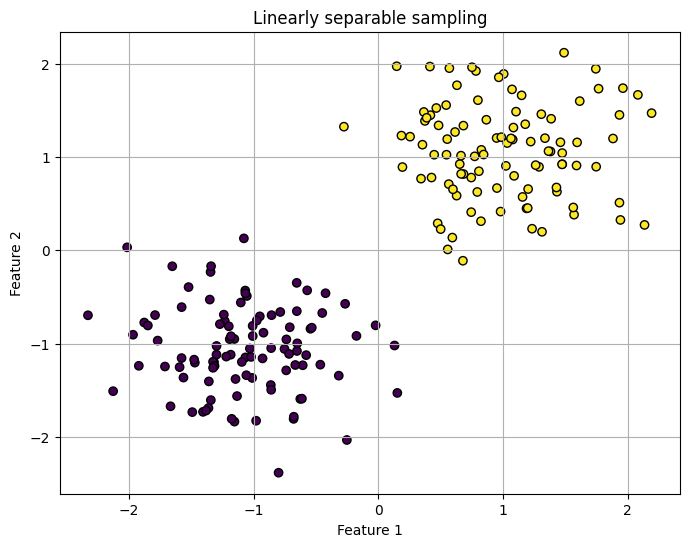

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 生成第一组点
np.random.seed(0)  # 为了结果的可重复性
n_points = 100
X1 = np.random.normal(size=(n_points, 2)) * 0.5 + np.array([1, 1])
Y1 = np.ones(n_points)

# 生成第二组点
X2 = np.random.normal(size=(n_points, 2)) * 0.5 + np.array([-1, -1])
Y2 = np.zeros(n_points)

# 数据合并
X = np.vstack((X1, X2))
Y = np.hstack((Y1, Y2))

# 数据可视化
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap='viridis', edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Linearly separable sampling')
plt.grid(True)
plt.show()


В случае линейной разделимости выборки модель машинного обучения, способная обеспечить идеальное качество классификации, выглядит очень просто:
$$f(\vec x, Θ) = Θ_0 + Θ_1^T\vec x$$

В случае правильно подобранных параметров $Θ$, такая модель способна идеально классифицировать выборку. Такая задача классификации называется **линейной**.

Конечно, такие функции не обеспечивают идеальную или даже удовлетворительную классификацию любого набора данных, даже при условии существования *некоторой* регулярности, разделяющей два класса. Например, мы можем поставить перед собой задачу классификации радиального набора данных:


在样本线性可分的情况下，能够提供理想分类质量的机器学习模型看起来非常简单：
$$f(\vec x, Θ) = Θ_0 + Θ_1^T\vec x$$

如果参数$Θ$选择正确，这样的模型就能够完美地对样本进行分类。这个分类问题被称为**线性**。

当然，即使两个类别之间存在某种规律，这样的函数也无法对任何数据集提供完美甚至令人满意的分类。例如，我们可以设定对径向数据集进行分类的任务：

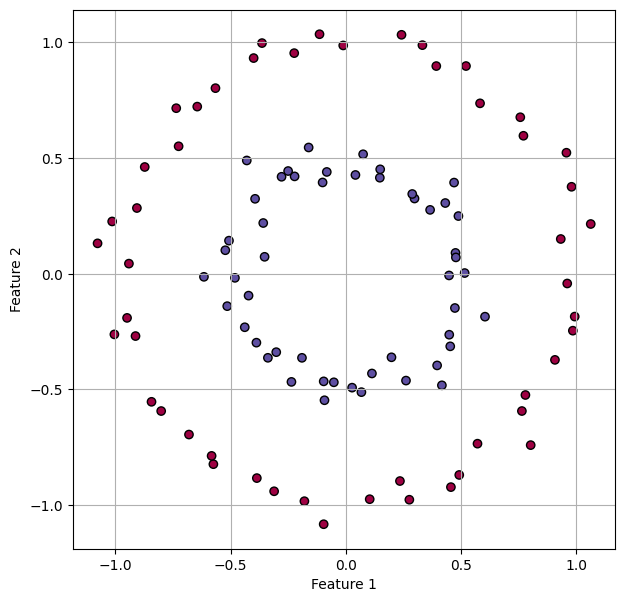

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

# 生成数据样本
np.random.seed(0)
X, y = datasets.make_circles(noise=0.05, factor=0.5, random_state=42)

# 结果可视化
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Spectral)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

Какое решение для этой проблемы можно придумать?

Кажется, самое простое и очевидное - изменить модель. Давайте вместо линейной модели $f(\vec x, Θ) = Θ_0 + Θ_1^T\vec x$ выберем другое семейство:
$$f_r(x_1, x_2, Θ) = \theta_1x_1^2 + \theta_2x_2^2 + Θ_0$$

Например, при $Θ_1 = Θ_2 = 1$ и $Θ_0 = -0.75^2$, уравнение $$f_{r}(x_1, x_2, Θ) = 0$$ задает окружность радиуса $0.75$ в пространстве признаков $x_1$ и $x_2$:

针对这个问题能想到什么解决办法呢？

看起来最简单、最明显的事情就是改变模型。让我们选择另一个系列来代替线性模型 $f(\vec x, Θ) = Θ_0 + Θ_1^T\vec x$：
$$f_r(x_1, x_2, Θ) = \theta_1x_1^2 + \theta_2x_2^2 + Θ_0$$

例如，当 $Θ_1 = Θ_2 = 1$ 且 $Θ_0 = -0.75^2$ 时，方程 $$f_{r}(x_1, x_2, Θ) = 0$$ 在特征空间 $x_1$ 和 $x_2$ 中定义了一个半径为 $0.75$ 的圆：

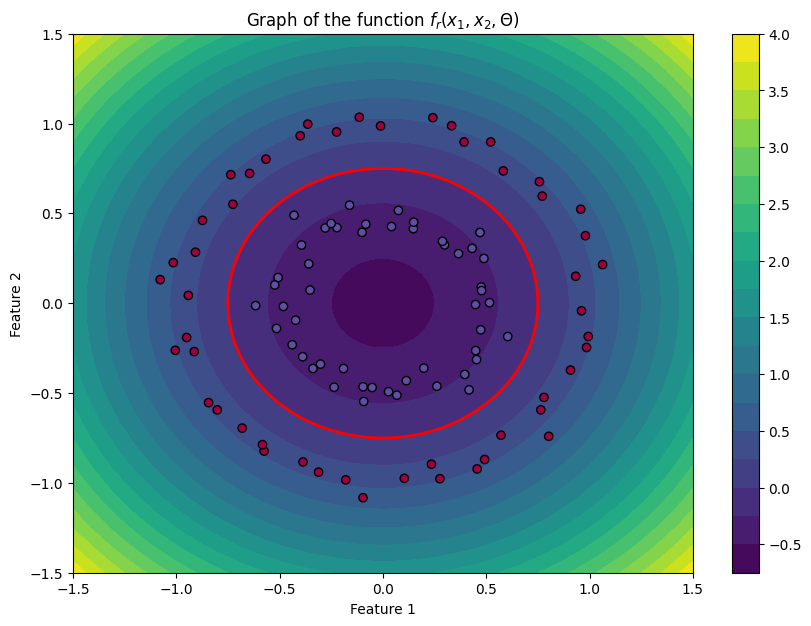

In [ ]:
Theta_1 = Theta_2 = 1
Theta_0 = -0.75**2

# 为 x1 和 x2 创建值网格
x1 = np.linspace(-1.5, 1.5, 100)
x2 = np.linspace(-1.5, 1.5, 100)
X1, X2 = np.meshgrid(x1, x2)

# 计算函数f_r的值
Z = Theta_1 * X1**2 + Theta_2 * X2**2 + Theta_0

# 结果可视化
plt.figure(figsize=(10, 7))
contour = plt.contourf(X1, X2, Z, levels=20, cmap='viridis')
plt.colorbar(contour)
plt.title('Graph of the function $f_r(x_1, x_2, \\Theta)$')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Spectral)
plt.contour(X1, X2, Z, levels=[0], colors='r', linewidths=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

У такого подхода есть два довольно важных недостатка:

1. В рамках такого подхода придется каждый раз "изобретать" новое семейство решающих функций, а затем оптимизировать его параметры. Это ручная работа, которую было бы неплохо оптимизировать или хотя бы превратить в переборную

2. В примере выше мы имеем дело с нелинейной задачей. Это сложно, как с технической точки зрения, так и с точки зрения аналитического анализа рассматриваемых моделей. Всегда предпочтительно работать с линейными моделями

**Вывод:** нужно переформулировать подход в универсальной терминологии, которая позволит а) взглянуть на задачу, как на линейную и б) поможет систематизировать возможные разумные семейства функций, которые мы можем использовать для решения подавляющего большинства задач

这种方法有两个相当重要的缺点：

1. 在这种方法的框架内，每次都需要“发明”一组新的决策函数，然后优化其参数。这是一项手动工作，最好进行优化，或者至少将其转变为强力工作。

2. 在上面的例子中，我们正在处理一个非线性问题。无论从技术角度还是从所考虑模型的分析角度来看，这都很困难。使用线性模型总是更好的。

**结论：**我们需要用一种通用术语来重新表述这种方法，这将使我们能够 a) 将问题视为线性问题；b) 帮助系统化可能合理的函数系列，以便我们用来解决绝大多数问题。

## Изменение пространства признаков

Другой взгляд на преобразование семейства функций, которое мы осуществили выше, состоит в следующем. Обратим внимание, что функция $f_r(x_1, x_2, Θ) = \theta_1x_1^2 + \theta_2x_2^2 + Θ_0$ **линейна относительно аргументов $x_1^2$ и $x_2^2$**. То есть мы можем воспринимать этот переход не как переход от одного семейства решающих функций к другому, а как использование той же самой линейной модели, но примененной уже к другому **преобразованному** пространству признаков. В этом новом прространстве мы получим уже совершенно другое облако точек:

改变特征空间

另一种观察我们上面进行的函数族变换的方法如下。请注意，函数 $f_r(x_1, x_2, Θ) = \theta_1x_1^2 + \theta_2x_2^2 + Θ_0$ **关于参数 $x_1^2$ 和 $x_2^2$** 是线性的。也就是说，我们可以将这种转变视为不是从一组决策函数到另一组决策函数的转变，而是使用相同的线性模型，但应用于不同的**变换**特征空间。在这个新的空间中，我们将得到完全不同的点云：

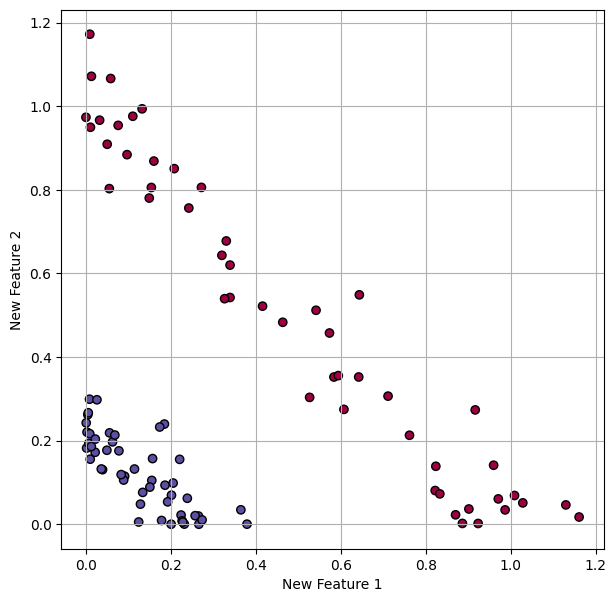

In [ ]:
np.random.seed(0)
X, y = datasets.make_circles(noise=0.05, factor=0.5, random_state=42)

# 结果可视化
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0]**2, X[:, 1]**2, c=y, edgecolors='k', cmap=plt.cm.Spectral)
plt.xlabel('New Feature 1')
plt.ylabel('New Feature 2')
plt.grid(True)
plt.show()

В этом пространстве облако, соответствующие классу "1", очень просто отделяются от облака, соответствующего классу "0" при помощи линейной функции.

在这个空间中，对应于类“1”的云很容易通过线性函数与对应于类“0”的云分离。

Можем мы здесь воспользоваться и другими возможными преобразованиями признаков. Например, подойдет переход к признакам

$$ \phi_1(\vec x) = x_1^2 + x_2^2$$
$$ \phi_2(\vec x) = x_1^2 - x_2^2$$

Вообще новые признаки мы будем обозначать буквой $ϕ$. Этих признаков может быть вообще говоря может быть сколько угодно, поэтому мы будем записывать их в виде вектор-функции векторного же аргумента:
$$\vec ϕ(\vec x) = [ϕ_1(\vec x), ϕ_2(\vec x) ... ]$$

我们还可以在这里使用其他可能的特征转换。例如，过渡到功能即可

$$ \phi_1(\vec x) = x_1^2 + x_2^2$$
$$ \phi_2(\vec x) = x_1^2 - x_2^2$$

一般来说，我们会用字母$ϕ$来表示新特征。一般来说，这些特征可以有任意数量，因此我们将它们写为向量参数的向量函数：
$$\vec ϕ(\vec x) = [ϕ_1(\vec x), ϕ_2(\vec x) ... ]$$

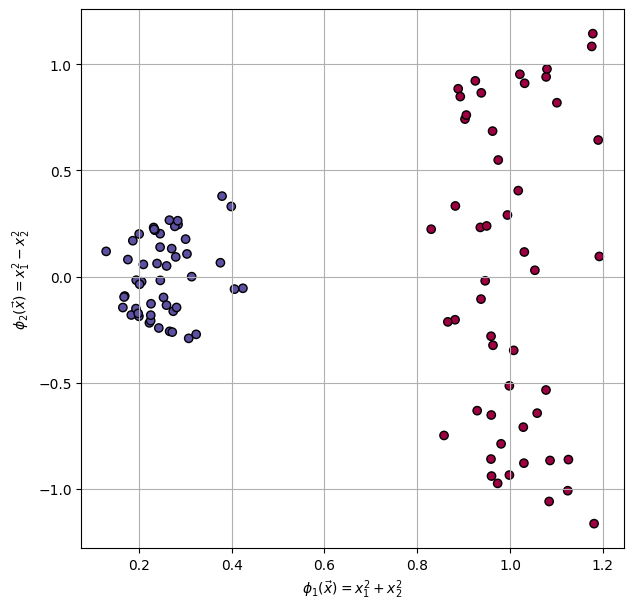

In [ ]:
np.random.seed(0)
X, y = datasets.make_circles(noise=0.05, factor=0.5, random_state=42)

# 结果可视化
plt.figure(figsize=(7, 7))
plt.scatter(X[:, 0]**2 + X[:, 1]**2, X[:, 0]**2 - X[:, 1]**2, c=y, edgecolors='k', cmap=plt.cm.Spectral)
plt.xlabel(r'$\phi_1(\vec x) = x_1^2 + x_2^2$')
plt.ylabel(r'$\phi_2(\vec x) = x_1^2 - x_2^2$')
plt.grid(True)
plt.show()

## Kernel Trick

Мы выяснили, что переход от одного признакового пространства к другому посредством применения к исходному вектору признаков $\vec x$ некоторой векторной функции $\vec ϕ(\vec x) = [\phi_1(\vec{x}), \phi_2(\vec{x}) ... ]$ позволяет нам перейти от нелинейной задачи классификации к линейной при правильном выборе этой функции $\vec \phi$. Возникает вопрос - как правильно подбирать эту функцию $\vec \phi$ и можно ли хотя бы частично автоматизировать этот процесс?

Чтобы ответить на этот вопрос, обратимся к некоторым следствиям области математики, которая называется **функциональный анализ**. Мы не будем подробно описывать условия и следствия, которые формулируются в теории воспроизводящих гильбертовых пространств, в связи со сложностью этой области для неподготовленного слушателя. Вместо этого нестрого сформулируем следующее  утверждение:

Пусть у нас есть некоторая функция $\vec \phi$, производящая интересующее нас преобразование исходного признакового пространства. Тогда существует такая функция $K: X × X → R$, что $$K(\vec x, \vec x') = ⟨\vec ϕ(\vec x), \vec ϕ(\vec x')⟩$$

Где под операцией $⟨\vec a, \vec b⟩$ подразумевается скалярное произведение.

内核技巧

我们发现，通过将原始特征向量 $\vec x$ 应用某个向量函数 $\vec ϕ(\vec x) = [\phi_1(\vec{x}), \phi_2(\vec{x}) ... ]$ 来实现从一个特征空间到另一个特征空间的转换，使我们能够通过正确选择此函数 $\vec \phi$ ，从非线性分类问题转移到线性分类问题。问题出现了——如何正确选择这个函数 $\vec \phi$，以及是否有可能至少部分地自动化这个过程？

为了回答这个问题，让我们来看一下数学领域的一些称为**泛函分析**的结论。我们不会详细描述再现希尔伯特空间的理论中制定的条件和后果，因为对于没有准备的听众来说这个领域太复杂了。相反，我们松散地制定以下陈述：

让我们有一些函数 $\vec \phi$ 来产生我们感兴趣的原始特征空间的变换。然后存在一个函数 $K: X × X → R$ 使得 $$K(\vec x, \vec x') = ⟨\vec ϕ(\vec x), \vec ϕ(\vec x')⟩$$

其中运算 $⟨\vec a, \vec b⟩$ 表示标量积。

То есть **каждому преобразованию признакового пространства $ϕ$ соответствует некоторая функция K, которая задает скалярное произведение в преобразованном пространстве как функцию от элементов исходного пространтсва**. Это утверждение позволяет нам сделать следующий шаг и взглянуть на переход от нелинейной модели к линейной не просто за счет преобразований, примененных к признакам, а как на **изменения функции, задающей скалярное произведение**. Условно говоря, переопределив скалярное произведение специальным образом, мы получим интересующее нас изменение модели $f$. Тут нужно отметить, что это относится, конечно, к тем моделям, которые в принципе основаны на вычислении скалярного произведения между объектами исходного пространства. Хорошим примером такой модели служит $SVM$.

也就是说，**特征空间$ϕ$的每一个变换都对应着一个特定的函数K，该函数将变换空间中的标量积定义为原空间元素的函数**。这个陈述使我们能够更进一步地观察从非线性模型到线性模型的转变，这不仅仅是由于对特征应用了变换，而且是由于**定义标量积的函数的变化**。传统上来说，通过以特殊的方式重新定义标量积，我们可以获得我们感兴趣的模型 $f$ 的变化。这里需要注意的是，这当然适用于那些原则上基于原始空间对象之间的标量积计算的模型。这种模型的一个很好的例子是$SVM$。

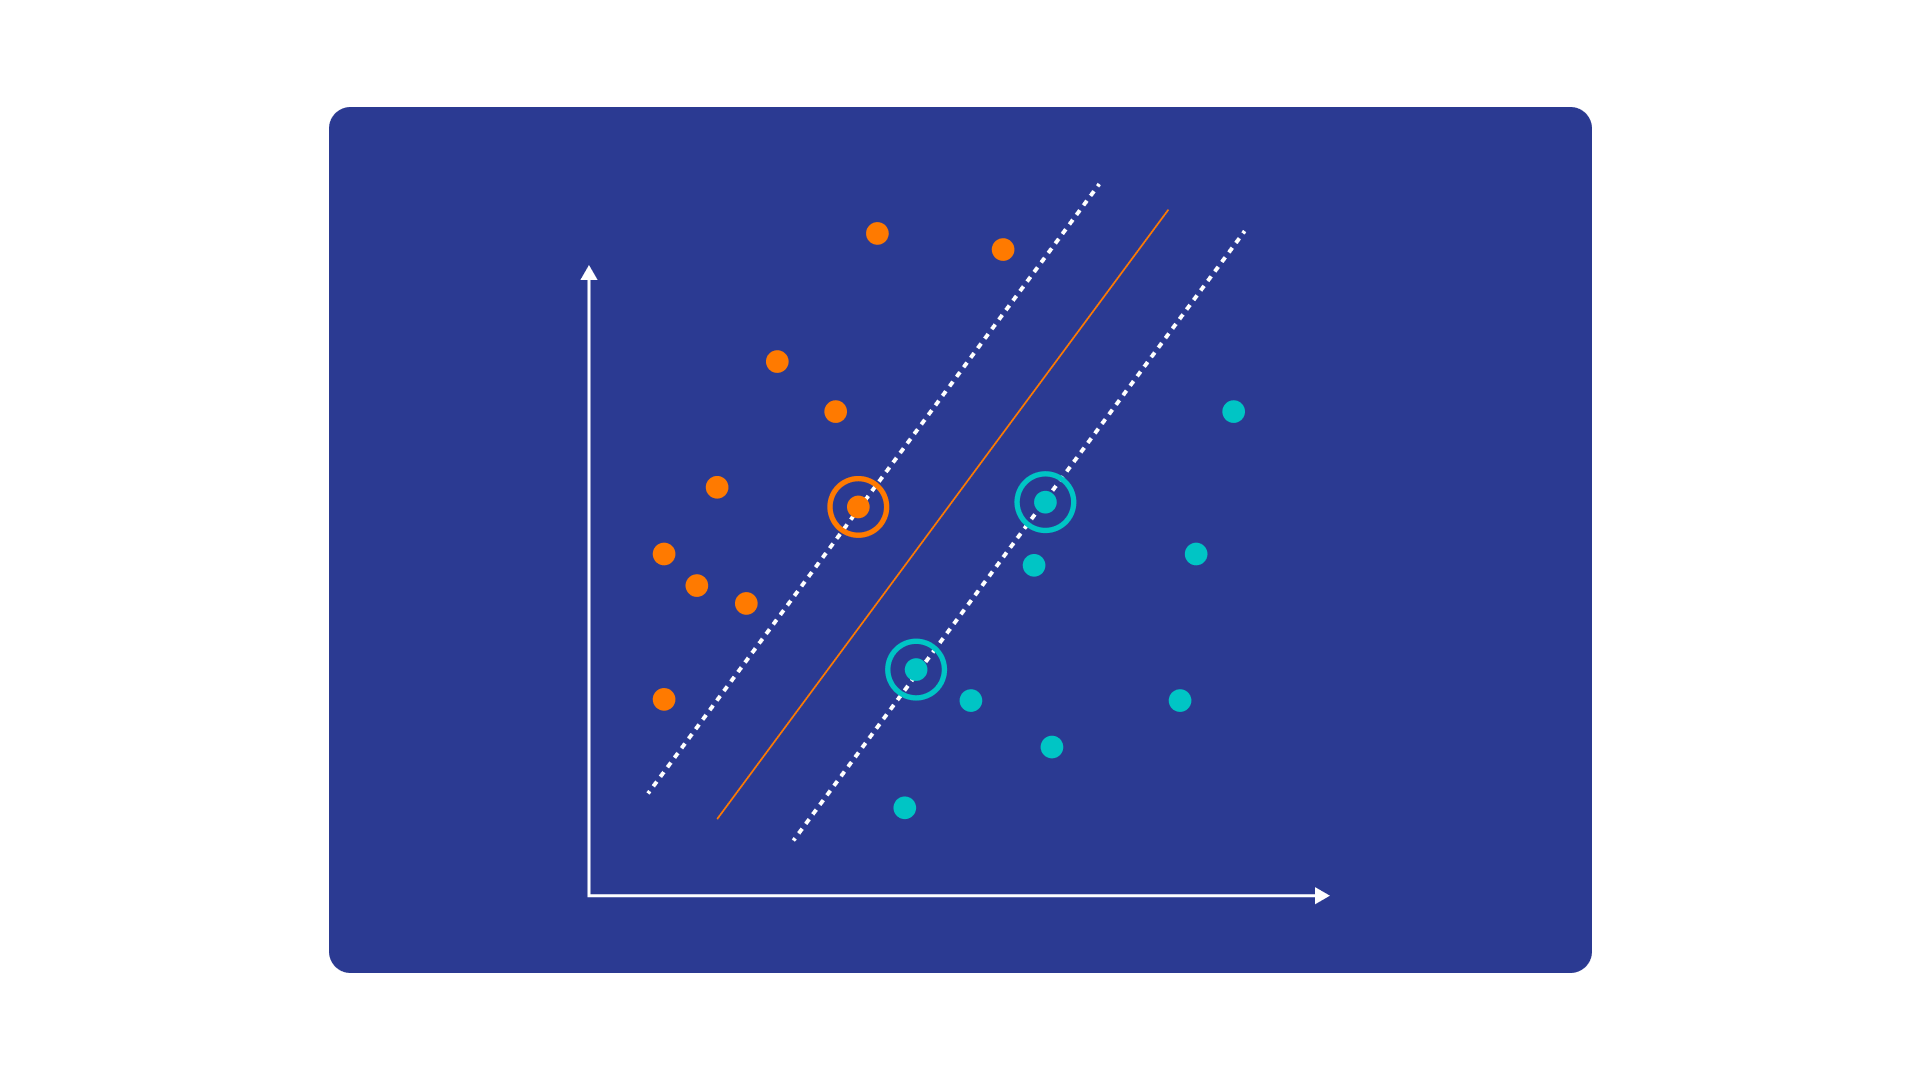

Напомню основную концепцию метода опорных векторов: мы строим раззделяющую гиперплоскость, отвечающую **критерию максимизации ширины полосы**, отделяющей один класс от другого. При этом возникает задача оптимизации, решаемая методоми квадратичного программирования. Перейдем сразу к рассмотрению решения этой проблемы.

В результате решения задачи квадратического программирования мы имеем набор коэффициентов $λ_i$ и решающее правило:

$$a(x) = sign\big{[}∑\lambda_iy_i\langle \vec x_i, \vec x \rangle - ∑λ_iy_i \langle \vec x_i, \vec x_j ⟩ - y_i\big{]}$$

Тут: $\vec x$ - объект, класс которого мы определяем, $\vec x_i$ - объект обучающей выборки с индексом $i$, $y_i$ - метка объекта обучающей выборки с индексом $i$ (+1 или -1).

Заменим в этой формуле скалярное произведение на вычисление некоторой функции $K(\vec x, \vec x')$ и получим:

$$a(x) = sign\big{[}∑\lambda_iy_iK( \vec x_i, \vec x ) - ∑λ_iy_i K( \vec x_i, \vec x_j ) - y_i\big{]}$$

Где конкретный вид $K$ зависит от того, какое преобразование признаков мы хотим выполнить. В исходном пространстве построенная разделяющая функция уже будет **нелинейной**, хотя вид выражения остался прежним.

Такой переход к формуле с функцией $K$ обычно называют **Kernel Trick**, а саму функцию $K$ - **ядром** (**kernel**).

让我提醒一下你支持向量机的基本概念：我们构建一个分离超平面，满足将一个类与另一个类分开的**最大化带宽标准**。这产生了一个优化问题，可以使用二次规划方法解决。让我们继续考虑这个问题的解决方案。

通过求解二次规划问题，我们得到一组系数 $λ_i$ 和一个决策规则：

$$a(x) = sign\big{[}∑\lambda_iy_i\langle \vec x_i, \vec x \rangle - ∑λ_iy_i \langle \vec x_i, \vec x_j ⟩ - y_i\big{]}$$

这里：$\vec x$是我们正在定义其类的对象，$\vec x_i$是索引为$i$的训练样本对象，$y_i$是索引为$i$的训练样本对象的标签（+1或-1）。

让我们将该公式中的标量积替换为某个函数 $K(\vec x, \vec x')$ 的计算，并得到：

$$a(x) = sign\big{[}∑\lambda_iy_iK( \vec x_i, \vec x ) - ∑λ_iy_i K( \vec x_i, \vec x_j ) - y_i\big{]}$$

其中$K$的具体形式取决于我们想要执行什么特征变换。在原始空间中，构造的分离函数虽然表达式的形式保持不变，但已经是**非线性**的。

这种向具有 $K$ 函数的公式的转变通常称为 **核技巧**，而 $K$ 函数本身称为 **核**。

## RBF-ядро

Для решения задачи с двумя круговыми классами мы также можем воспользоваться **Kernel Trick**. Для этого мы воспользуемся очень известным типом ядра, который называется **RBF**(Radial Basis Function). RBF зависит только от расстояния между двумя аргументами

$$ K(x, y) = \exp\left(-\frac{|x-y|^2}{2\sigma^2}\right) $$

где:

* $(K(x, y))$ — значение ядра на паре аргументов $(x)$ и $(y)$,
* $(|\cdot|)$ обозначает евклидову норму ,
* $(\sigma)$ — параметр масштаба, который влияет на ширину ядра.

Как и обычное скалярное произведение, RBF оценивает меру близости между своими аргументами, Но в некотором "искаженном" пространстве. Например, если мы зафиксируем один из аргументов, то график этой близости в зависимости от второго аргумента будет выглядеть не линейно, а как гауссиана:

RBF 核心

为了解决具有两个循环类的问题，我们还可以使用**核技巧**。为此，我们将使用一种非常著名的核类型，称为**RBF**（径向基函数）。 RBF 仅取决于两个参数之间的距离

$$ K(x, y) = \exp\left(-\frac{|x-y|^2}{2\sigma^2}\right) $$

在哪里：

* $(K(x, y))$ 是参数对 $(x)$ 和 $(y)$ 的核值，
* $(|\cdot|)$ 表示欧几里得范数，
* $(\sigma)$ 是一个影响核宽度的比例参数。

与常规点积类似，RBF 估计其参数之间的接近度，但是是在某些“扭曲”的空间中。例如，如果我们固定其中一个参数，那么取决于第二个参数的接近度图将看起来不是线性的，而是像高斯的：

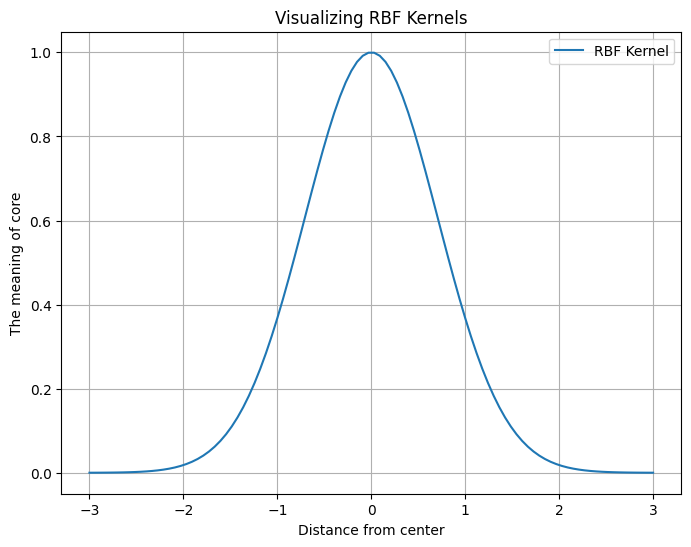

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义 RBF 核参数
center = 0
gamma = 1

# 生成可视化数据
x = np.linspace(-3, 3, 100)
rbf_values = np.exp(-gamma * (x - center)**2)

# 预览
plt.figure(figsize=(8, 6))
plt.plot(x, rbf_values, label='RBF Kernel')
plt.title('Visualizing RBF Kernels')
plt.xlabel('Distance from center')
plt.ylabel('The meaning of core')
plt.legend()
plt.grid(True)
plt.show()


В этом примере ядро рассматривалось как функция от пары скалярных аргументов. Этот случай сам по себе очень важный, потому что часто именно в таком виде ядра используются в математической статистике (но об этом мы поговорим ниже). Но применить ядро можно, конечно, и в случае, когда аргументы - векторы.

В фреймворке `sklearn` есть возможность использовать нелинейные ядра напрямую с `SVM`. Для этого достаточно указать тип ядра, которое мы хотим использовать, напрямую при определении класса `SVC`, как это делается в примере ниже.

在这个例子中，核被视为一对标量参数的函数。这种情况本身非常重要，因为核在数理统计中通常以这种形式使用（但我们将在下文中讨论这一点）。但当然，当参数是向量时也可以使用内核。

`sklearn` 框架能够将非线性核直接与 `SVM` 一起使用。为此，只需在定义“SVC”类时直接指定我们想要使用的内核类型，如下例所示。

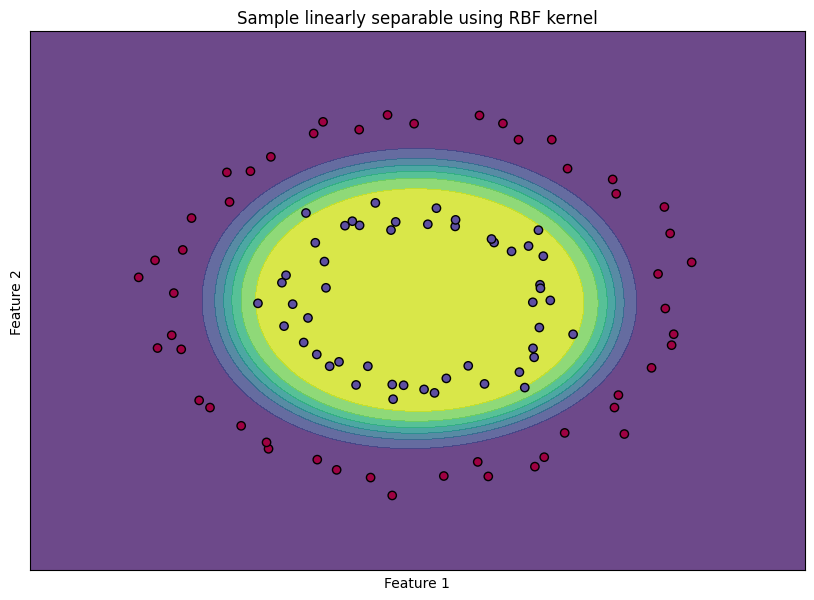

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC

# 生成数据样本
np.random.seed(0)
X, y = datasets.make_circles(noise=0.05, factor=0.5, random_state=42)

# 使用 RBF 核训练 SVM
clf = SVC(kernel='rbf', C=1, probability=True).fit(X, y)

# 创建可视化网格
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 500),
                     np.linspace(-1.5, 1.5, 500))
Z = clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1]
Z = Z.reshape(xx.shape)

# 结果可视化
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Spectral)
plt.title('Sample linearly separable using RBF kernel')
plt.grid()
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())
plt.show()


## Другие примеры ядер

Помимо **RBF** существует множество других типов ядерных функций. Рассмотрим некоторые из них:

其他内核示例

除了**RBF**之外，还有许多其他类型的核函数。让我们来看看其中的一些：

### Линейное ядро

Использование линейного ядра возможно в предположении, что данные заранее имеют линейные зависимости. Линейное ядро представляет из себя стандартное скалярное произведение и является "дефолтным" выбором при тестировании алгоритма.

$$K(\vec x, \vec y) = \gamma \vec x^T \vec y $$

线性核心

在假设数据预先具有线性依赖性的情况下，可以使用线性核。线性核是标准点积，是测试算法时的“默认”选择。

$$K(\vec x, \vec y) = \gamma \vec x^T \vec y $$

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119909 (\N{MATHEMATICAL ITALIC SMALL X}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 119910 (\N{MATHEMATICAL ITALIC SMALL Y}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


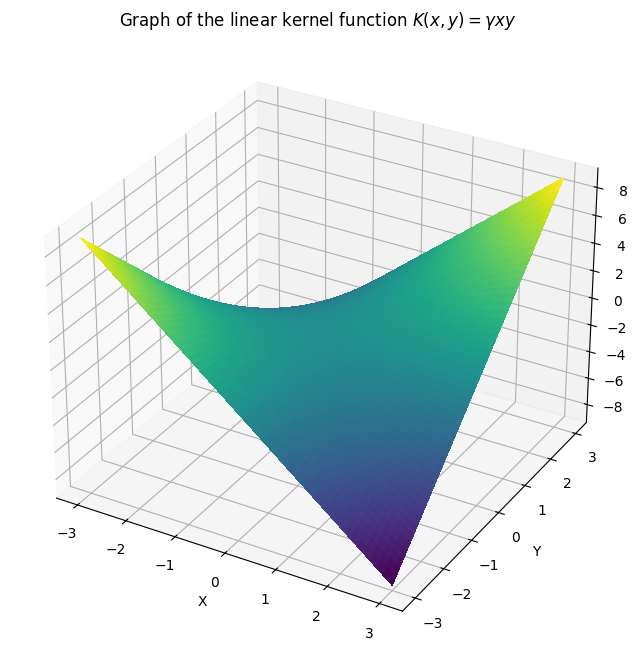

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 参数
gamma = 1

# 数据生成
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = gamma * X * Y  # 计算线性核函数的值

# 创建 3D 图形
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 表面可视化
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)

# 设置轴
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('K(𝑥, 𝑦)')
ax.set_title(r'Graph of the linear kernel function $K(x, y) = γxy$')

plt.show()


### Полиномиальное ядро

Полиномиальное ядро - логичное обобщение линейного ядра. Мы предполагаем, что зависимости, которые мы ищем в данных, имеют полиномиальный характер, то есть зависят не только от первой степени аргументов, но и от высших степеней. Полинномиальное ядро задается следующей формулой:

$$K(\vec x, \vec y) = (γ \vec x^T \vec y + c)^d $$

Где $d$ - степень многочлена, задающего ядро.

多项式核

多项式核是线性核的逻辑概括。我们假设在数据中寻找的依赖关系本质上是多项式的，也就是说，它们不仅取决于参数的第一次次数，还取决于更高的次数。多项式核由以下公式给出：

$$K(\vec x, \vec y) = (γ \vec x^T \vec y + c)^d $$

其中 $d$ 是定义核的多项式的度。

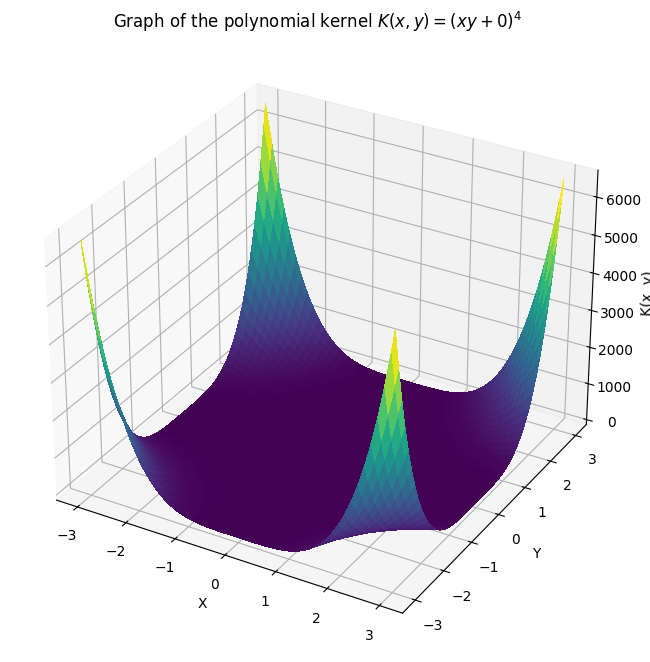

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 参数
c = 0
d = 4

# 数据生成
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = (X * Y + c)**d  # 计算多项式核的值

# 创建 3D 图形
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 表面可视化
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)

# 设置轴
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('K(x, y)')
ax.set_title(fr'Graph of the polynomial kernel $K(x, y) = (xy + {c})^{d}$')

plt.show()


### Сигмоидальное ядро

Также одно из популярных ядер, задаваемое двумя параметрами. Оно вычисляется по следующей формуле:

$$K(\vec x, \vec y) = tanh(γ\vec x^T \vec y + c)$$

Несмотря на свой специфический вид, сигмоидальное ядро довольно часто используется на практике.

Здесь $tanh(x)$ - это функция **гиперболического тангенса**, которая задается следующим образом:

$$tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

Sigmoid 内核

也是流行的内核之一，由两个参数指定。使用以下公式计算：

$$K(\vec x, \vec y) = tanh(γ\vec x^T \vec y + c)$$

尽管外观特殊，但 S 型核在实践中却经常使用。

这里 $tanh(x)$ 是**双曲正切**函数，其公式如下：

$$tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

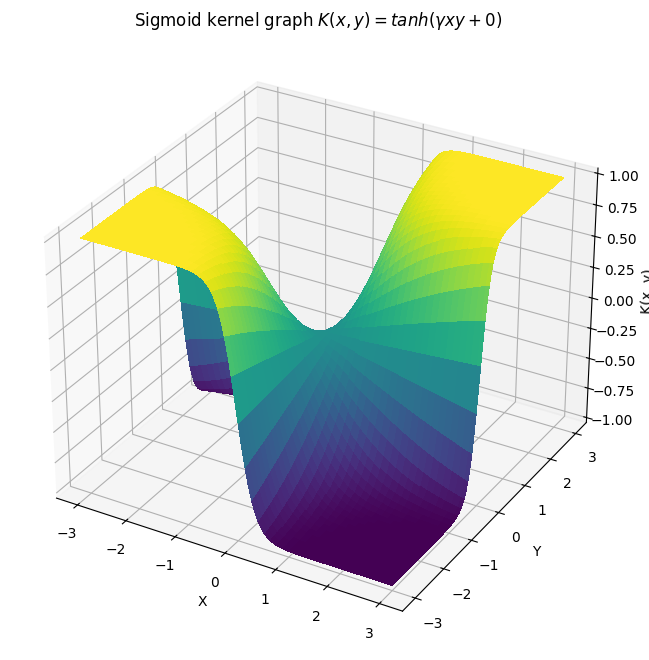

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 参数
gamma = 1
c = 0

# 数据生成
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.tanh(gamma * X * Y + c)  # 计算多项式核的值

# 创建 3D 图形
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 表面可视化
surf = ax.plot_surface(X, Y, Z, cmap='viridis', linewidth=0, antialiased=False)

# 设置轴
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('K(x, y)')
ax.set_title(fr'Sigmoid kernel graph $K(x, y) = tanh(γxy + {c})$')
plt.show()

### Пример использования различных ядер

В этом примере мы посмотрим на влияние применения различных ядер для решения задачи классификации. Мы рассмотрим линейное, полиномиальное со степенями 2 и 3, RBF, а также сигмоидальное ядра. Код, представленный ниже, является модификацией кода Gaël Varoquaux и Andreas Müller, размещенного на [официальной странице](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py) sklearn, посвященной сравнению различных классификаторов.

使用不同内核的示例

在这个例子中，我们将研究使用不同的内核解决分类问题的影响。我们将考虑线性、2 次和 3 次多项式、RBF 和 S 型核。下面的代码是 Gaël Varoquaux 和 Andreas Müller 在 [官方](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py) sklearn 页面上发布的用于比较不同分类器的代码的修改版。

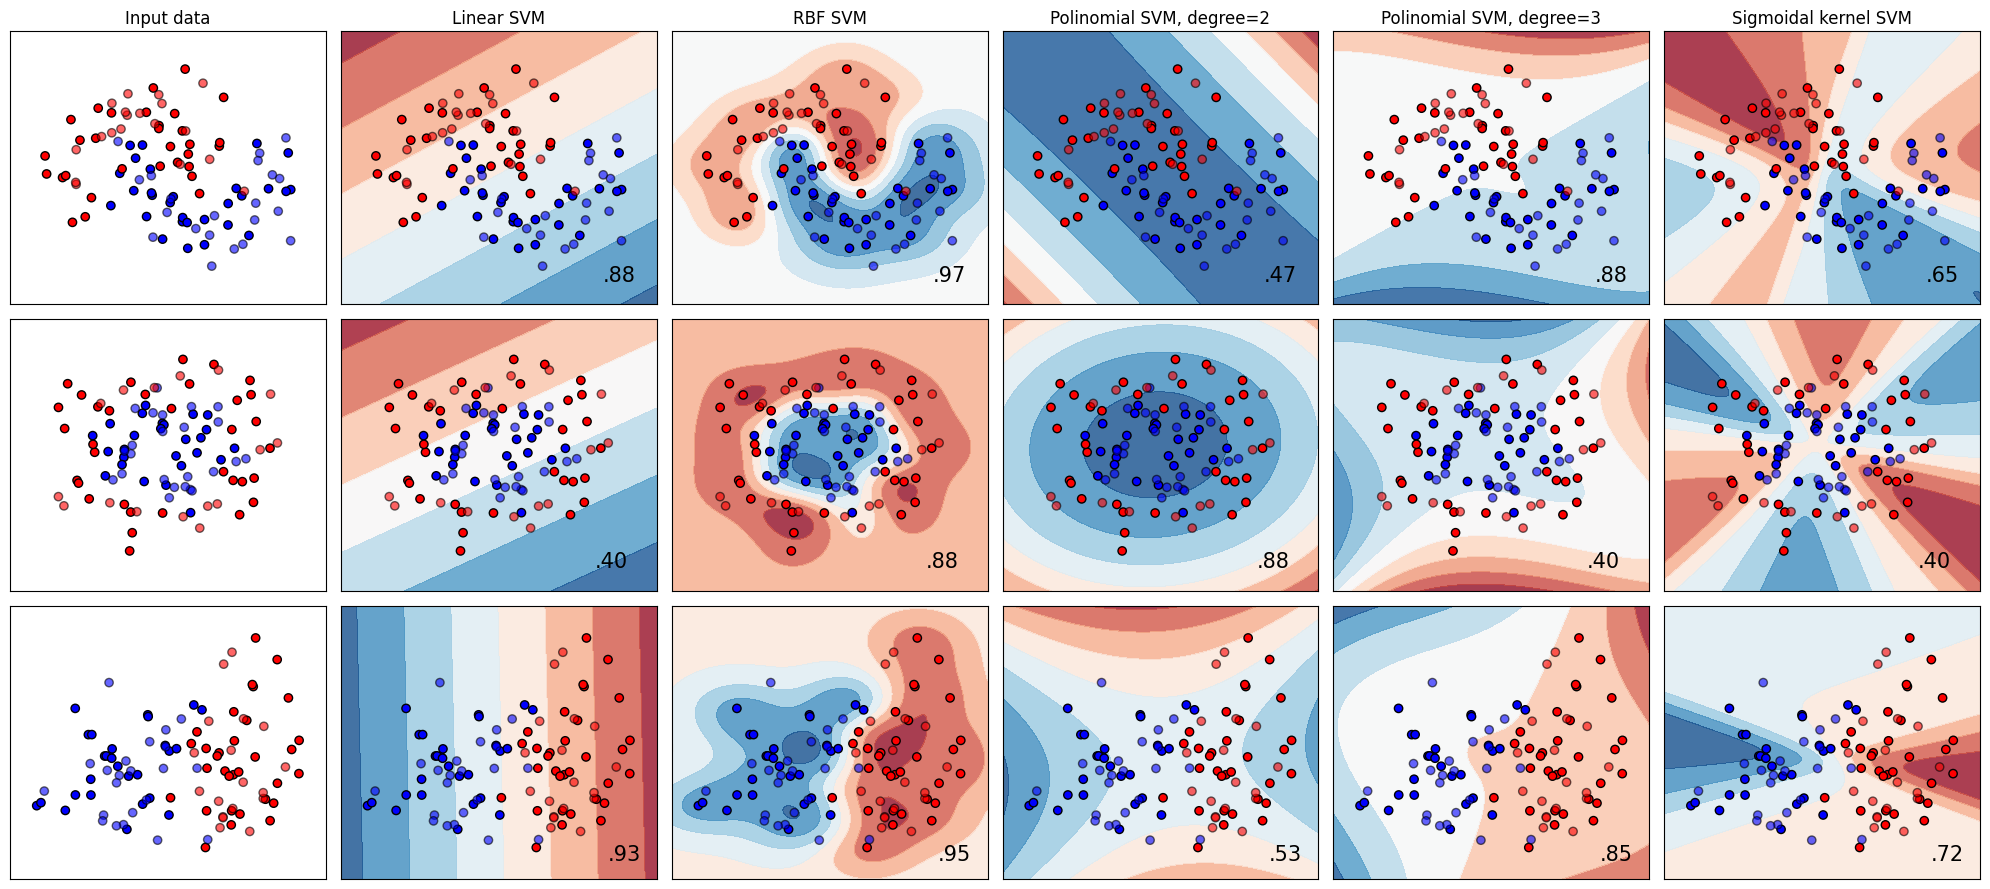

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import make_circles, make_classification, make_moons
from sklearn.gaussian_process.kernels import RBF
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

names = [
    "Linear SVM",
    "RBF SVM",
    "Polinomial SVM, degree=2",
    "Polinomial SVM, degree=3",
    "Sigmoidal kernel SVM"
]

classifiers = [
    SVC(kernel="linear", C=0.025, random_state=42),
    SVC(gamma=2, C=1, random_state=42),
    SVC(C=1.0, kernel='poly', degree=2, gamma=2),
    SVC(C=1.0, kernel='poly', degree=3, gamma=2),
    SVC(C=1.0, kernel='sigmoid', degree=3, gamma=2)
]

X, y = make_classification(
    n_features=2, n_redundant=0, n_informative=2, random_state=1, n_clusters_per_class=1
)
rng = np.random.RandomState(2)
X += 2 * rng.uniform(size=X.shape)
linearly_separable = (X, y)

datasets = [
    make_moons(noise=0.3, random_state=0),
    make_circles(noise=0.2, factor=0.5, random_state=1),
    linearly_separable,
]

figure = plt.figure(figsize=(20, 9))
i = 1
# iterate over datasets
for ds_cnt, ds in enumerate(datasets):
    # preprocess dataset, split into training and test part
    X, y = ds
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=42
    )

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # just plot the dataset first
    cm = plt.cm.RdBu
    cm_bright = ListedColormap(["#FF0000", "#0000FF"])
    ax = plt.subplot(len(datasets), len(classifiers) + 1, i)
    if ds_cnt == 0:
        ax.set_title("Input data")
    # Plot the training points
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    # Plot the testing points
    ax.scatter(
        X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k"
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    i += 1

    # iterate over classifiers
    for name, clf in zip(names, classifiers):
        ax = plt.subplot(len(datasets), len(classifiers) + 1, i)

        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(X_train, y_train)
        score = clf.score(X_test, y_test)
        DecisionBoundaryDisplay.from_estimator(
            clf, X, cmap=cm, alpha=0.8, ax=ax, eps=0.5
        )

        # Plot the training points
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k"
        )
        # Plot the testing points
        ax.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_test,
            cmap=cm_bright,
            edgecolors="k",
            alpha=0.6,
        )

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_xticks(())
        ax.set_yticks(())
        if ds_cnt == 0:
            ax.set_title(name)
        ax.text(
            x_max - 0.3,
            y_min + 0.3,
            ("%.2f" % score).lstrip("0"),
            size=15,
            horizontalalignment="right",
        )
        i += 1

plt.tight_layout()
plt.show()

## Ядра в статистике

Многие ядра задаются функцией от разности аргументов, то есть являются в этом смысле функцией одного аргумента:
$$K(\vec x, \vec x') = K(||\vec x - \vec x'||)$$

Если смотреть на ядро, как на функцию одного аргумента, для функции ядра можно дать следующее более практичное, но несколько отличающееся определение:

**Ядро - неотрицательная вещественнозначная нормированная симметричная функция**.

Таким определением пользуются в математической статистике. Очень часто на ядра в этом смысле накладывается еще одно условие:
$$\int_{-∞}^{+∞}{K(u)du} = 1$$

Одно из основных применений ядерных функций в статистике - **непараметрическая оценка плотности распределения**.


统计学中的核

许多内核是由参数差异的函数定义的，也就是说，从这个意义上来说，它们是一个参数的函数：
$$K(\vec x, \vec x') = K(||\vec x - \vec x'||)$$

如果我们将核视为一个参数的函数，则可以对核函数给出以下更实用但略有不同的定义：

**核是一个非负实值归一化对称函数**。

这个定义用于数理统计。通常，对内核还会施加另一个条件：
$$\int_{-∞}^{+∞}{K(u)du} = 1$$

核函数在统计学中的主要应用之一是**非参数密度估计**。

### Kernel Density Estimation (KDE)

Оценка параметров распределения - это большая задача математической статистики. Она заключается в том, чтобы **по набору наблюдений** (сэмплов) определить, **из какого распределения этот набор получился**. Методы решения этой задачи глобально делятся на 2 типа: параметрические и непараметрические. Параметрические методы - это методы, основанные на гипотезе о том, что мы примерно представляем, к какому семейству распределений относится искомое, и достаточно оценить его неизвестные параметры. Параметрическая статистика занимается в основном такими оценками.

Однако совершенно не всегда такие предположения можно сделать. Иногда требуется хотя бы примерно оценить функцию плостности распределения без привлечения дополнительных предположений и гипотез. В таком случае на помощь приходит **непараметрические** методы. Одним из таких методов является **ядерная оценка плотности** (Kernel Density Estimation).



核密度估计（KDE）

分布参数估计是数理统计中的一个主要问题。它包括**使用一组观察结果**（样本）来确定**该集合来自什么分布**。解决这个问题的方法总体上分为两类：参数化和非参数化。参数方法是基于这样的假设的方法：我们大致知道所需分布属于哪个分布族，并且足以估计其未知参数。参数统计主要处理此类估计。

然而，并不总是能够做出这样的假设。有时有必要至少近似地估计分布密度函数，而无需使用额外的假设和假设。在这种情况下，**非参数**方法可以解决问题。其中一种方法是核密度估计。

Формула ядерного оценщика плотности распределения следующая:

$$ \hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{|x - X_i|}{h}\right)$$

Функция $\hat{f}_h(x)$ - это оценка плотности распределения, из которого был сэмплирован набор наблюдений $X_1 ... X_N$. Эта плотность в каждой конкретной точке $x$ зависит от всех наблюдений, взятых с некоторым весом, который вычисляется при помощи соответствующего ядра.
Здесь $h$ - это дополнительный параметр, представляющий из себя *ширину полосы сглаживания*. На расстоянии, превышающим $h$ от $x$, влияние наблюдений $X_i$ очень мало или равно $0$ (в зависимости от типа ядра).

核密度估计量的公式为：

$$ \hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{|x - X_i|}{h}\right)$$

函数 $\hat{f}_h(x)$ 是从一组观测值 $X_1 ... X_N$ 中抽样的分布密度的估计值。每个特定点 $x$ 处的密度取决于以一定权重进行的所有观测，该权重是使用适当的内核计算的。
这里$h$是一个附加参数，代表*平滑带宽*。在距 $x$ 大于 $h$ 的距离处，观测值 $X_i$ 的影响非常小或等于 $0$（取决于核的类型）。

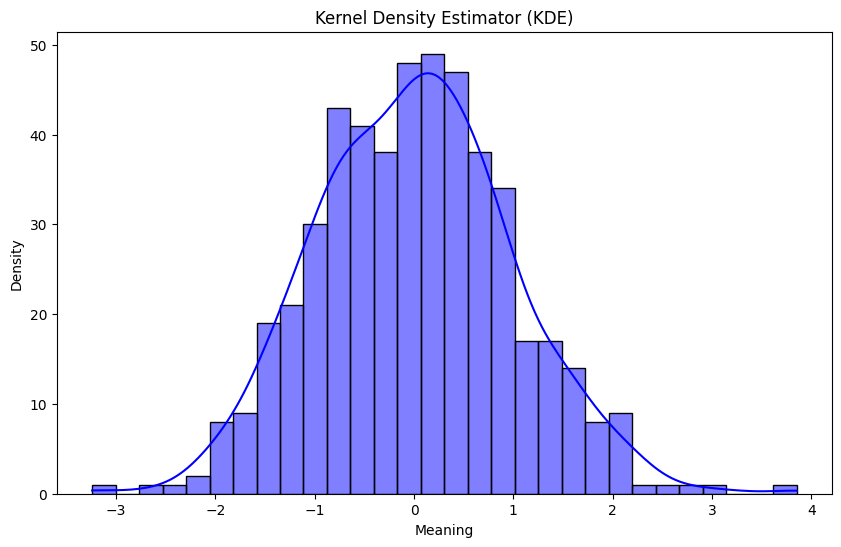

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 从正态分布生成样本
np.random.seed(42)  # 为了结果的可重复性
sample_size = 500
sample = np.random.normal(loc=0, scale=1, size=sample_size)

# 创建 KDE 图
plt.figure(figsize=(10, 6))

# 添加直方图以便比较
sns.histplot(sample, kde=True, bins=30, color='blue', alpha=0.5)


plt.title('Kernel Density Estimator (KDE)')
plt.xlabel('Meaning')
plt.ylabel('Density')

plt.show()


## Дополнительная литература:

1. Kernel Methods for Machine Learning with Math and Python, Joe Suzuki, 2022
2. Learning with Kernels, Bernhard Schölkopf and Alexander J. Smola
3. Kernel Methods and Machine Learning, S. Y. Kung


进一步阅读：

1. 使用数学和 Python 进行机器学习的核方法，Joe Suzuki，2022 年
2. Learning with Kernels，Bernhard Schölkopf 和 A​​lexander J. Smola
3. 核方法与机器学习，S. Y. Kung